<a href="https://colab.research.google.com/github/Oksana0020/Cloud-Computing-Project/blob/main/CloudComputing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Cloud Computing Project

#Efficient Management of Large-Scale Lip-Reading Datasets Using Manifest-Based Serverless Architectures on AWS

*Lip-reading Dataset Management Notebook*

### Storage and cost calculation setup

10-video sample was measured directly in AWS S3.

Measured values from AWS:
- One set of extracted frame images for 10 videos: **3.7 MB**
- All generated manifest files for the same 10 videos: **203.4 KB**
- File-based storage duplicates the same frame data across **3 viseme systems**

From these measurements I performed the following calcualtions:

- **Manifest-based storage for 10 videos**  
  = 3.7 MB + (203.4 KB / 1024)  
  ≈ **3.9 MB**

- **File-based storage for 10 videos**  
  = 3.7 MB × 3  
  = **11.1 MB**

These values I converted into per-video constants and used to estimate storage for larger datasets by linear scaling.

Per-video constants used in this notebook:
- **Manifest-based per video** = **0.39 MB**
- **File-based per video** = **1.11 MB**

Datasets used in this notebook:
- **GRID partial subset used for personal FYP research:** 10,000 videos
- **GRID full corpus:** 34,000 videos
- **BBC LRW:** 500,000 clips
- **BBC LRS2:** 144,482 videos
- **BBC LRS3:** 151,819 videos

Estimated storage costs are computed using AWS calculator. Initial idea was to stick to standard AWS pricing:
- **Amazon S3 Standard = $0.023 per GB-month**

For the final comparison table, monthly costs for the larger datasets are taken directly from the AWS Pricing Calculator using the corresponding storage totals in GB-month.  
The 10-video baseline cost is derived by proportional scaling from the 10,000-video AWS Calculator result, because small amounts are not available for calculation on AWS calculator.

Annual costs are computed from monthly values multiply by 12, and savings are calculated as difference between file-based and manifest-based storage.

## Constants, storage estimates and AWS cost setup

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

VIDEOS_SAMPLE = 10
frames_storage_mb_sample = 3.7
manifests_storage_kb_sample = 203.4
manifests_storage_mb_sample = manifests_storage_kb_sample / 1024
manifest_total_mb_sample = round(
    frames_storage_mb_sample + manifests_storage_mb_sample, 1)
file_total_mb_sample = round(
    frames_storage_mb_sample * 3, 1)

# Storage reduction percentage
storage_saved_pct = round(
    ((file_total_mb_sample - manifest_total_mb_sample) / file_total_mb_sample) * 100, 1)

# Per video constants used for all larger datasets
manifest_per_video_mb = round(manifest_total_mb_sample / VIDEOS_SAMPLE, 2)
file_per_video_mb = round(file_total_mb_sample / VIDEOS_SAMPLE, 2)
s3_price_per_gb = 0.023
GRID_10K_VIDEOS = 10_000
GRID_34K_VIDEOS = 34_000
LRW_VIDEOS = 500_000
LRS2_VIDEOS = 144_482
LRS3_VIDEOS = 151_819


def build_storage_cost_scenario(dataset_name: str, video_count: int):
    """
    Build storage and estimated cost values
    manifest_per_video_mb = 0.39 MB/video
    file_per_video_mb= 1.11 MB/video
    """
    # storage
    manifest_mb = round(video_count * manifest_per_video_mb, 1)
    file_mb = round(video_count * file_per_video_mb, 1)
    manifest_gb = round(manifest_mb / 1024, 2)
    file_gb = round(file_mb / 1024, 2)
    wasted_gb = round(file_gb - manifest_gb, 2)
    # Estimated monthly cost
    manifest_month = round(manifest_gb * s3_price_per_gb, 2)
    file_month = round(file_gb * s3_price_per_gb, 2)
    saving_month = round(file_month - manifest_month, 2)
    # Estimated annual cost
    manifest_year = round(manifest_month * 12, 2)
    file_year = round(file_month * 12, 2)
    saving_year = round(saving_month * 12, 2)
    return {
        "dataset": dataset_name, "videos": video_count,
        "manifest_mb": manifest_mb, "file_mb": file_mb,
        "manifest_gb": manifest_gb, "file_gb": file_gb,
        "wasted_gb": wasted_gb, "manifest_month": manifest_month,
        "file_month": file_month, "saving_month": saving_month,
        "manifest_year": manifest_year, "file_year": file_year,
        "saving_year": saving_year}

# Build storage cost estimate scenarios
sample_10 = build_storage_cost_scenario("GRID (Clinical sample, 10 videos)", 10)
grid_10k = build_storage_cost_scenario("GRID (Partial, 10,000 videos)", GRID_10K_VIDEOS)
grid_34k = build_storage_cost_scenario("GRID (Full, 34,000 videos)", GRID_34K_VIDEOS)
lrw_full = build_storage_cost_scenario("BBC LRW (Full, 500,000 videos)", LRW_VIDEOS)
lrs2_full = build_storage_cost_scenario("BBC LRS2 (Full, 144,482 videos)", LRS2_VIDEOS)
lrs3_full = build_storage_cost_scenario("BBC LRS3 (Full, 151,819 videos)", LRS3_VIDEOS)

# storage values
aws_calc_storage = {
    "GRID_10K":   {"manifest_gb": 3.81,   "file_gb": 10.84},
    "GRID_34K":   {"manifest_gb": 12.95,  "file_gb": 36.86},
    "LRW_500K":   {"manifest_gb": 190.43, "file_gb": 541.99},
    "LRS2_144K":  {"manifest_gb": 55.03,  "file_gb": 156.61},
    "LRS3_152K":  {"manifest_gb": 57.82,  "file_gb": 164.56}}
for key, vals in aws_calc_storage.items():
    vals["wasted_gb"] = round(vals["file_gb"] - vals["manifest_gb"], 2)

# Monthly costs from AWS Calculator
aws_calc_costs = {
    "GRID_10K": {"manifest_month": 0.09, "file_month": 0.25},
    "GRID_34K": {"manifest_month": 0.30, "file_month": 0.85},
    "LRW_500K": {"manifest_month": 4.38, "file_month": 12.47},
    "LRS2_144K": {"manifest_month": 1.27, "file_month": 3.60},
    "LRS3_152K": {"manifest_month": 1.33, "file_month": 3.78}}
for key, vals in aws_calc_costs.items():
    vals["saving_month"] = round(vals["file_month"] - vals["manifest_month"], 2)
    vals["manifest_year"] = round(vals["manifest_month"] * 12, 2)
    vals["file_year"] = round(vals["file_month"] * 12, 2)
    vals["saving_year"] = round(vals["saving_month"] * 12, 2)

# 10-video baseline cost got from 10K video AWS calculator values
scale_down_10_from_10k = 10 / 10_000
sample_10_calc_manifest_month = round(
    aws_calc_costs["GRID_10K"]["manifest_month"] * scale_down_10_from_10k, 5)
sample_10_calc_file_month = round(
    aws_calc_costs["GRID_10K"]["file_month"] * scale_down_10_from_10k, 5)
sample_10_calc_saving_month = round(
    sample_10_calc_file_month - sample_10_calc_manifest_month, 5)
sample_10_calc_manifest_year = round(sample_10_calc_manifest_month * 12, 5)
sample_10_calc_file_year = round(sample_10_calc_file_month * 12, 5)
sample_10_calc_saving_year = round(sample_10_calc_saving_month * 12, 5)

# storage and costs for datasets
# GRID 10K videos
manifest_grid_10k_gb = aws_calc_storage["GRID_10K"]["manifest_gb"]
file_grid_10k_gb = aws_calc_storage["GRID_10K"]["file_gb"]
wasted_grid_10k_gb = aws_calc_storage["GRID_10K"]["wasted_gb"]
manifest_cost_grid_10k_month = aws_calc_costs["GRID_10K"]["manifest_month"]
file_cost_grid_10k_month = aws_calc_costs["GRID_10K"]["file_month"]
saving_grid_10k_month = aws_calc_costs["GRID_10K"]["saving_month"]
manifest_cost_grid_10k_year = aws_calc_costs["GRID_10K"]["manifest_year"]
file_cost_grid_10k_year = aws_calc_costs["GRID_10K"]["file_year"]
saving_grid_10k_year = aws_calc_costs["GRID_10K"]["saving_year"]

# GRID 34K videos
manifest_grid_34k_gb = aws_calc_storage["GRID_34K"]["manifest_gb"]
file_grid_34k_gb = aws_calc_storage["GRID_34K"]["file_gb"]
wasted_grid_34k_gb = aws_calc_storage["GRID_34K"]["wasted_gb"]
manifest_cost_grid_34k_month = aws_calc_costs["GRID_34K"]["manifest_month"]
file_cost_grid_34k_month = aws_calc_costs["GRID_34K"]["file_month"]
saving_grid_34k_month = aws_calc_costs["GRID_34K"]["saving_month"]
manifest_cost_grid_34k_year = aws_calc_costs["GRID_34K"]["manifest_year"]
file_cost_grid_34k_year = aws_calc_costs["GRID_34K"]["file_year"]
saving_grid_34k_year = aws_calc_costs["GRID_34K"]["saving_year"]

# LRW 500K videos
manifest_lrw_gb = aws_calc_storage["LRW_500K"]["manifest_gb"]
file_lrw_gb = aws_calc_storage["LRW_500K"]["file_gb"]
wasted_lrw_gb = aws_calc_storage["LRW_500K"]["wasted_gb"]
manifest_cost_lrw_month = aws_calc_costs["LRW_500K"]["manifest_month"]
file_cost_lrw_month = aws_calc_costs["LRW_500K"]["file_month"]
saving_lrw_month = aws_calc_costs["LRW_500K"]["saving_month"]
manifest_cost_lrw_year = aws_calc_costs["LRW_500K"]["manifest_year"]
file_cost_lrw_year = aws_calc_costs["LRW_500K"]["file_year"]
saving_lrw_year = aws_calc_costs["LRW_500K"]["saving_year"]

# LRS2 144,482 videos
manifest_lrs2_gb = aws_calc_storage["LRS2_144K"]["manifest_gb"]
file_lrs2_gb = aws_calc_storage["LRS2_144K"]["file_gb"]
wasted_lrs2_gb = aws_calc_storage["LRS2_144K"]["wasted_gb"]
manifest_cost_lrs2_month = aws_calc_costs["LRS2_144K"]["manifest_month"]
file_cost_lrs2_month = aws_calc_costs["LRS2_144K"]["file_month"]
saving_lrs2_month = aws_calc_costs["LRS2_144K"]["saving_month"]
manifest_cost_lrs2_year = aws_calc_costs["LRS2_144K"]["manifest_year"]
file_cost_lrs2_year = aws_calc_costs["LRS2_144K"]["file_year"]
saving_lrs2_year = aws_calc_costs["LRS2_144K"]["saving_year"]

# LRS3 151,819 videos
manifest_lrs3_gb = aws_calc_storage["LRS3_152K"]["manifest_gb"]
file_lrs3_gb = aws_calc_storage["LRS3_152K"]["file_gb"]
wasted_lrs3_gb = aws_calc_storage["LRS3_152K"]["wasted_gb"]
manifest_cost_lrs3_month = aws_calc_costs["LRS3_152K"]["manifest_month"]
file_cost_lrs3_month = aws_calc_costs["LRS3_152K"]["file_month"]
saving_lrs3_month = aws_calc_costs["LRS3_152K"]["saving_month"]
manifest_cost_lrs3_year = aws_calc_costs["LRS3_152K"]["manifest_year"]
file_cost_lrs3_year = aws_calc_costs["LRS3_152K"]["file_year"]
saving_lrs3_year = aws_calc_costs["LRS3_152K"]["saving_year"]

# arrays ready for plots
dataset_short_storage = ["GRID\n(10K)", "GRID\n(34K)", "LRW\n(500K)", "LRS2\n(144K)", "LRS3\n(152K)"]
manifest_gb_v = [
    manifest_grid_10k_gb,
    manifest_grid_34k_gb,
    manifest_lrw_gb,
    manifest_lrs2_gb,
    manifest_lrs3_gb]

wasted_gb_v = [
    wasted_grid_10k_gb,
    wasted_grid_34k_gb,
    wasted_lrw_gb,
    wasted_lrs2_gb,
    wasted_lrs3_gb]

dataset_short_savings = ["GRID\n10K", "GRID\n34K", "LRW\n500K", "LRS2\n144K", "LRS3\n152K"]
savings_monthly = [
    saving_grid_10k_month,
    saving_grid_34k_month,
    saving_lrw_month,
    saving_lrs2_month,
    saving_lrs3_month]

annual_savings_all = [
    saving_grid_10k_year,
    saving_grid_34k_year,
    saving_lrw_year,
    saving_lrs2_year,
    saving_lrs3_year]

# Summary print
print("Core constants ready:")
print(f"  Manifest-based per video: {manifest_per_video_mb:.2f} MB")
print(f"  File-based per video:     {file_per_video_mb:.2f} MB")
print(f"  Storage reduction:        {storage_saved_pct:.1f}%")
print()
print()
print("AWS-aligned storage scenarios:")
print(f"  GRID 10K  -> {manifest_grid_10k_gb:.2f} GB vs {file_grid_10k_gb:.2f} GB")
print(f"  GRID 34K  -> {manifest_grid_34k_gb:.2f} GB vs {file_grid_34k_gb:.2f} GB")
print(f"  LRW 500K  -> {manifest_lrw_gb:.2f} GB vs {file_lrw_gb:.2f} GB")
print(f"  LRS2 144K -> {manifest_lrs2_gb:.2f} GB vs {file_lrs2_gb:.2f} GB")
print(f"  LRS3 152K -> {manifest_lrs3_gb:.2f} GB vs {file_lrs3_gb:.2f} GB")
print()
print()
print("AWS Calculator monthly costs:")
print(f"  GRID 10K  -> ${manifest_cost_grid_10k_month:.2f} vs ${file_cost_grid_10k_month:.2f}")
print(f"  GRID 34K  -> ${manifest_cost_grid_34k_month:.2f} vs ${file_cost_grid_34k_month:.2f}")
print(f"  LRW 500K  -> ${manifest_cost_lrw_month:.2f} vs ${file_cost_lrw_month:.2f}")
print(f"  LRS2 144K -> ${manifest_cost_lrs2_month:.2f} vs ${file_cost_lrs2_month:.2f}")
print(f"  LRS3 152K -> ${manifest_cost_lrs3_month:.2f} vs ${file_cost_lrs3_month:.2f}")
print()
print()
print("Derived 10-video baseline from GRID 10K results in AWS calculator:")
print(f"  ${sample_10_calc_manifest_month:.5f} vs ${sample_10_calc_file_month:.5f} per month")

Core constants ready:
  Manifest-based per video: 0.39 MB
  File-based per video:     1.11 MB
  Storage reduction:        64.9%


AWS-aligned storage scenarios:
  GRID 10K  -> 3.81 GB vs 10.84 GB
  GRID 34K  -> 12.95 GB vs 36.86 GB
  LRW 500K  -> 190.43 GB vs 541.99 GB
  LRS2 144K -> 55.03 GB vs 156.61 GB
  LRS3 152K -> 57.82 GB vs 164.56 GB


AWS Calculator monthly costs:
  GRID 10K  -> $0.09 vs $0.25
  GRID 34K  -> $0.30 vs $0.85
  LRW 500K  -> $4.38 vs $12.47
  LRS2 144K -> $1.27 vs $3.60
  LRS3 152K -> $1.33 vs $3.78


Derived 10-video baseline from GRID 10K results in AWS calculator:
  $0.00009 vs $0.00025 per month


## Comparison table

This table summarises the main storage and cost results from all datasets.

Monthly costs for the larger datasets are taken directly from the AWS Pricing Calculator in GB-month.

The table reports:
- manifest-based storage
- file-based storage
- percentage storage reduction
- actual cost per month
- actual cost per year
- monthly savings
- annual savings

Annual values are computed from monthly values and savings are calculated as difference between file-based and manifest-based storage.

In [81]:
def fmt_money(val):
    return f"${val:.5f}" if val < 0.01 else f"${val:.2f}"

rows = [{"Dataset": "GRID (Clinical sample, 10 videos)",
         "Videos": "10",
        "Manifest Storage": f"{sample_10['manifest_mb']:.1f} MB",
        "File-based Storage": f"{sample_10['file_mb']:.1f} MB",
        "Reduction": f"{storage_saved_pct:.1f}%",
        "Manifest Cost / Month": fmt_money(sample_10_calc_manifest_month),
        "File-based Cost / Month": fmt_money(sample_10_calc_file_month),
        "Manifest Cost / Year": fmt_money(sample_10_calc_manifest_year),
        "File-based Cost / Year": fmt_money(sample_10_calc_file_year),
        "Monthly Savings": fmt_money(sample_10_calc_saving_month),
        "Annual Savings": fmt_money(sample_10_calc_saving_year)},

    {"Dataset": "GRID (Partial, 10,000 videos)",
     "Videos": "10,000",
     "Manifest Storage": f"{manifest_grid_10k_gb:.2f} GB",
     "File-based Storage": f"{file_grid_10k_gb:.2f} GB",
     "Reduction": f"{storage_saved_pct:.1f}%",
     "Manifest Cost / Month": fmt_money(manifest_cost_grid_10k_month),
     "File-based Cost / Month": fmt_money(file_cost_grid_10k_month),
     "Manifest Cost / Year": fmt_money(manifest_cost_grid_10k_year),
     "File-based Cost / Year": fmt_money(file_cost_grid_10k_year),
     "Monthly Savings": fmt_money(saving_grid_10k_month),
     "Annual Savings": fmt_money(saving_grid_10k_year)},

    {"Dataset": "GRID (Full, 34,000 videos)",
     "Videos": "34,000",
     "Manifest Storage": f"{manifest_grid_34k_gb:.2f} GB",
     "File-based Storage": f"{file_grid_34k_gb:.2f} GB",
     "Reduction": f"{storage_saved_pct:.1f}%",
     "Manifest Cost / Month": fmt_money(manifest_cost_grid_34k_month),
     "File-based Cost / Month": fmt_money(file_cost_grid_34k_month),
     "Manifest Cost / Year": fmt_money(manifest_cost_grid_34k_year),
     "File-based Cost / Year": fmt_money(file_cost_grid_34k_year),
     "Monthly Savings": fmt_money(saving_grid_34k_month),
     "Annual Savings": fmt_money(saving_grid_34k_year)},

    {"Dataset": "BBC LRW (Full, 500,000 videos)",
     "Videos": "500,000",
     "Manifest Storage": f"{manifest_lrw_gb:.2f} GB",
     "File-based Storage": f"{file_lrw_gb:.2f} GB",
     "Reduction": f"{storage_saved_pct:.1f}%",
     "Manifest Cost / Month": fmt_money(manifest_cost_lrw_month),
     "File-based Cost / Month": fmt_money(file_cost_lrw_month),
     "Manifest Cost / Year": fmt_money(manifest_cost_lrw_year),
     "File-based Cost / Year": fmt_money(file_cost_lrw_year),
     "Monthly Savings": fmt_money(saving_lrw_month),
     "Annual Savings": fmt_money(saving_lrw_year)},

    {"Dataset": "BBC LRS2 (Full, 144,482 videos)",
     "Videos": "144,482",
     "Manifest Storage": f"{manifest_lrs2_gb:.2f} GB",
     "File-based Storage": f"{file_lrs2_gb:.2f} GB",
     "Reduction": f"{storage_saved_pct:.1f}%",
     "Manifest Cost / Month": fmt_money(manifest_cost_lrs2_month),
     "File-based Cost / Month": fmt_money(file_cost_lrs2_month),
     "Manifest Cost / Year": fmt_money(manifest_cost_lrs2_year),
     "File-based Cost / Year": fmt_money(file_cost_lrs2_year),
     "Monthly Savings": fmt_money(saving_lrs2_month),
     "Annual Savings": fmt_money(saving_lrs2_year)},

    {"Dataset": "BBC LRS3 (Full, 151,819 videos)",
     "Videos": "151,819", "Manifest Storage": f"{manifest_lrs3_gb:.2f} GB",
     "File-based Storage": f"{file_lrs3_gb:.2f} GB",
     "Reduction": f"{storage_saved_pct:.1f}%",
     "Manifest Cost / Month": fmt_money(manifest_cost_lrs3_month),
     "File-based Cost / Month": fmt_money(file_cost_lrs3_month),
     "Manifest Cost / Year": fmt_money(manifest_cost_lrs3_year),
     "File-based Cost / Year": fmt_money(file_cost_lrs3_year),
     "Monthly Savings": fmt_money(saving_lrs3_month),
     "Annual Savings": fmt_money(saving_lrs3_year)}]

comparison_df = pd.DataFrame(rows)
comparison_df.index = np.arange(1, len(comparison_df) + 1)
print(comparison_df.to_string())
comparison_df

                             Dataset   Videos Manifest Storage File-based Storage Reduction Manifest Cost / Month File-based Cost / Month Manifest Cost / Year File-based Cost / Year Monthly Savings Annual Savings
1  GRID (Clinical sample, 10 videos)       10           3.9 MB            11.1 MB     64.9%              $0.00009                $0.00025             $0.00108               $0.00300        $0.00016       $0.00192
2      GRID (Partial, 10,000 videos)   10,000          3.81 GB           10.84 GB     64.9%                 $0.09                   $0.25                $1.08                  $3.00           $0.16          $1.92
3         GRID (Full, 34,000 videos)   34,000         12.95 GB           36.86 GB     64.9%                 $0.30                   $0.85                $3.60                 $10.20           $0.55          $6.60
4     BBC LRW (Full, 500,000 videos)  500,000        190.43 GB          541.99 GB     64.9%                 $4.38                  $12.47           

,Dataset,Videos,Manifest Storage,File-based Storage,Reduction,Manifest Cost / Month,File-based Cost / Month,Manifest Cost / Year,File-based Cost / Year,Monthly Savings,Annual Savings
1,"GRID (Clinical sample, 10 videos)",10,3.9 MB,11.1 MB,64.9%,$0.00009,$0.00025,$0.00108,$0.00300,$0.00016,$0.00192
2,"GRID (Partial, 10,000 videos)","10,000",3.81 GB,10.84 GB,64.9%,$0.09,$0.25,$1.08,$3.00,$0.16,$1.92
3,"GRID (Full, 34,000 videos)","34,000",12.95 GB,36.86 GB,64.9%,$0.30,$0.85,$3.60,$10.20,$0.55,$6.60
4,"BBC LRW (Full, 500,000 videos)","500,000",190.43 GB,541.99 GB,64.9%,$4.38,$12.47,$52.56,$149.64,$8.09,$97.08
5,"BBC LRS2 (Full, 144,482 videos)","144,482",55.03 GB,156.61 GB,64.9%,$1.27,$3.60,$15.24,$43.20,$2.33,$27.96
6,"BBC LRS3 (Full, 151,819 videos)","151,819",57.82 GB,164.56 GB,64.9%,$1.33,$3.78,$15.96,$45.36,$2.45,$29.40


###Research methodology flowchart

This diagram illustrates the overall research workflow.

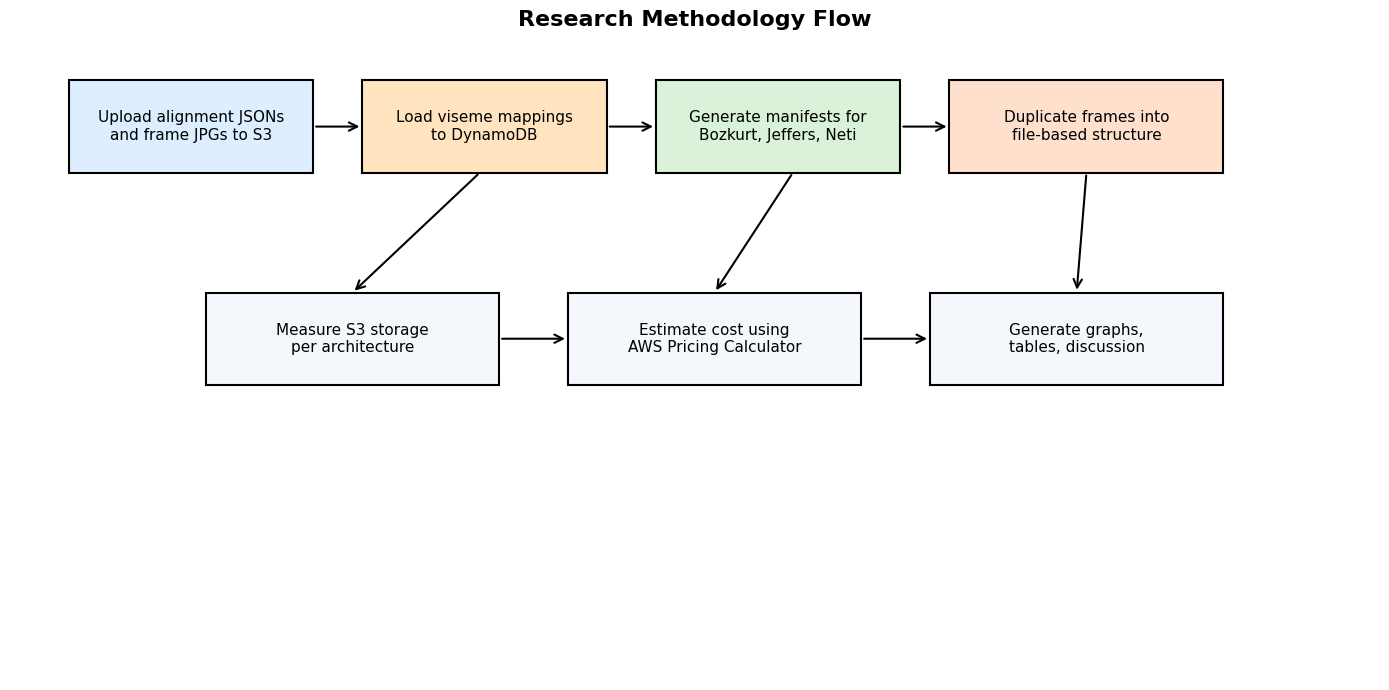

In [82]:
from matplotlib.patches import Rectangle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis("off")

def add_box(x, y, w, h, text, fc="#f4f7fb"):
    rect = Rectangle((x, y), w, h, facecolor=fc, edgecolor="black", linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=11, wrap=True)

def add_arrow(x1, y1, x2, y2):
    arrow = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='->', mutation_scale=15, linewidth=1.5)
    ax.add_patch(arrow)

add_box(0.6, 5.5, 2.5, 1.0, "Upload alignment JSONs\nand frame JPGs to S3", "#dceeff")
add_box(3.6, 5.5, 2.5, 1.0, "Load viseme mappings\nto DynamoDB", "#ffe4bf")
add_box(6.6, 5.5, 2.5, 1.0, "Generate manifests for\nBozkurt, Jeffers, Neti", "#d9f2d9")
add_box(9.6, 5.5, 2.8, 1.0, "Duplicate frames into\nfile-based structure", "#ffe0cc")
add_box(2.0, 3.2, 3.0, 1.0, "Measure S3 storage\nper architecture", "#f4f7fb")
add_box(5.7, 3.2, 3.0, 1.0, "Estimate cost using\nAWS Pricing Calculator", "#f4f7fb")
add_box(9.4, 3.2, 3.0, 1.0, "Generate graphs,\ntables, discussion", "#f4f7fb")
add_arrow(3.1, 6.0, 3.6, 6.0)
add_arrow(6.1, 6.0, 6.6, 6.0)
add_arrow(9.1, 6.0, 9.6, 6.0)
add_arrow(11.0, 5.5, 10.9, 4.2)
add_arrow(8.0, 5.5, 7.2, 4.2)
add_arrow(4.8, 5.5, 3.5, 4.2)
add_arrow(5.0, 3.7, 5.7, 3.7)
add_arrow(8.7, 3.7, 9.4, 3.7)
plt.title("Research Methodology Flow", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()

The following few cells with 10 videos results show initial steps in the research before scaling to large datasets. My initial aim was to investigate 10 videos and scale to 10,000 sample, but later on I decided to do estimations also for full datasets.

## Storage comparison for 10 videos

This graph compares the total storage required for the file-based and manifest-based approaches for the measured 10-video sample.

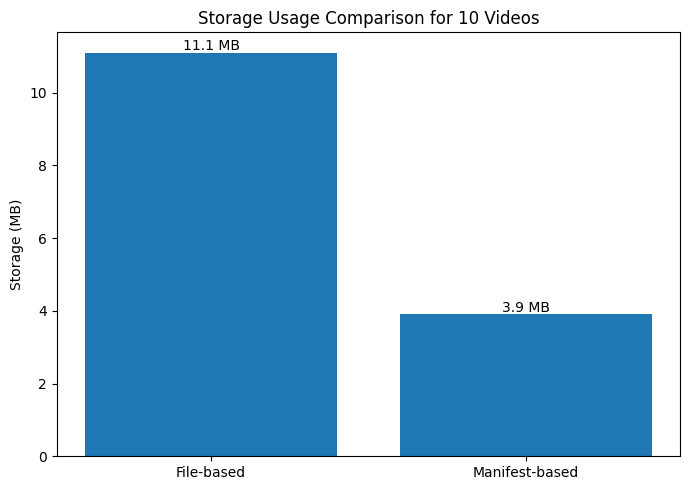

In [83]:
labels = ["File-based", "Manifest-based"]
storage_10 = [file_total_mb_sample, manifest_total_mb_sample]
plt.figure(figsize=(7, 5))
bars = plt.bar(labels, storage_10)
plt.ylabel("Storage (MB)")
plt.title("Storage Usage Comparison for 10 Videos")
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, y + 0.08, f"{y:.1f} MB", ha='center')
plt.tight_layout()
plt.savefig("graph_storage_10_videos_corrected.png", dpi=300, bbox_inches="tight")
plt.show()

## Monthly cost comparison for 10 videos

This graph shows the estimated monthly AWS S3 storage cost for the 10-video sample.

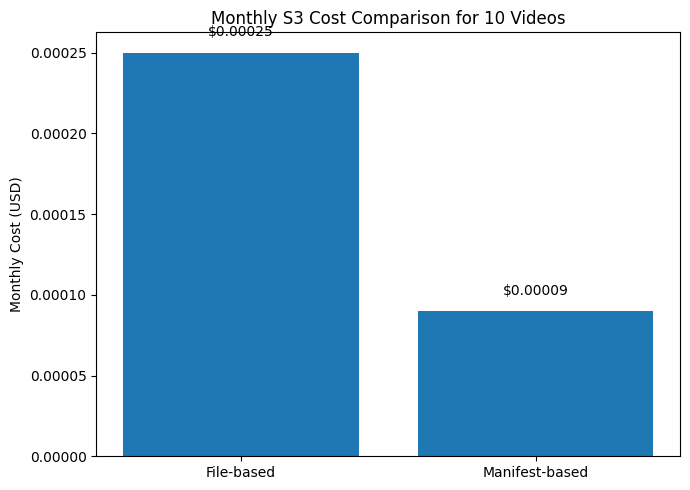

In [84]:
labels = ["File-based", "Manifest-based"]
cost_10 = [sample_10_calc_file_month, sample_10_calc_manifest_month]
plt.figure(figsize=(7, 5))
bars = plt.bar(labels, cost_10)
plt.ylabel("Monthly Cost (USD)")
plt.title("Monthly S3 Cost Comparison for 10 Videos")
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, y + 0.00001, f"${y:.5f}", ha='center')
plt.tight_layout()
plt.savefig("graph_cost_10_videos_corrected.png", dpi=300, bbox_inches="tight")
plt.show()

## Storage scaling from 10 to 10,000 videos

This graph shows how storage requirements increase as dataset size grows from 10 to 10,000 videos.

The file-based approach remains consistently larger because it duplicates frame data across viseme systems.

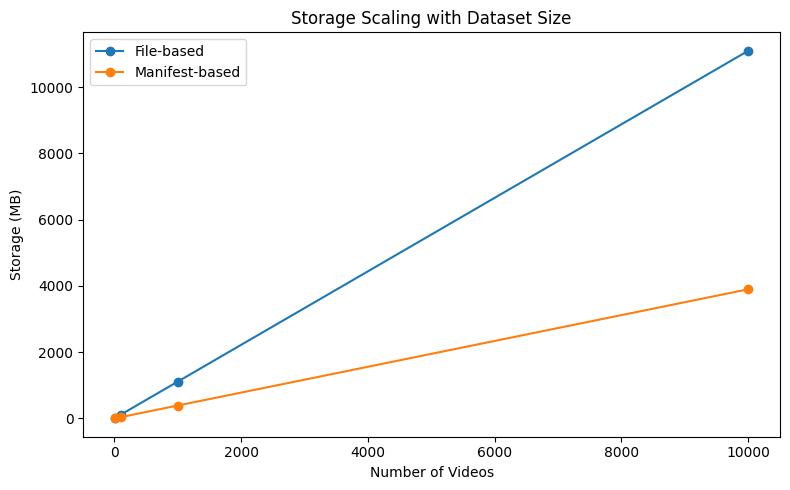

In [85]:
video_counts = np.array([10, 100, 1000, 10000])
file_storage_mb = file_per_video_mb * video_counts
manifest_storage_mb = manifest_per_video_mb * video_counts
plt.figure(figsize=(8, 5))
plt.plot(video_counts, file_storage_mb, marker='o', label='File-based')
plt.plot(video_counts, manifest_storage_mb, marker='o', label='Manifest-based')
plt.xlabel("Number of Videos")
plt.ylabel("Storage (MB)")
plt.title("Storage Scaling with Dataset Size")
plt.legend()
plt.tight_layout()
plt.savefig("graph_storage_scaling_corrected.png", dpi=300, bbox_inches="tight")
plt.show()

## Cost scaling from 10 to 10,000 videos

This graph shows how monthly AWS S3 storage cost increases as the dataset grows from 10 to 10,000 videos.

Because the file-based approach stores duplicated data, its storage cost grows faster than manifest-based approach.

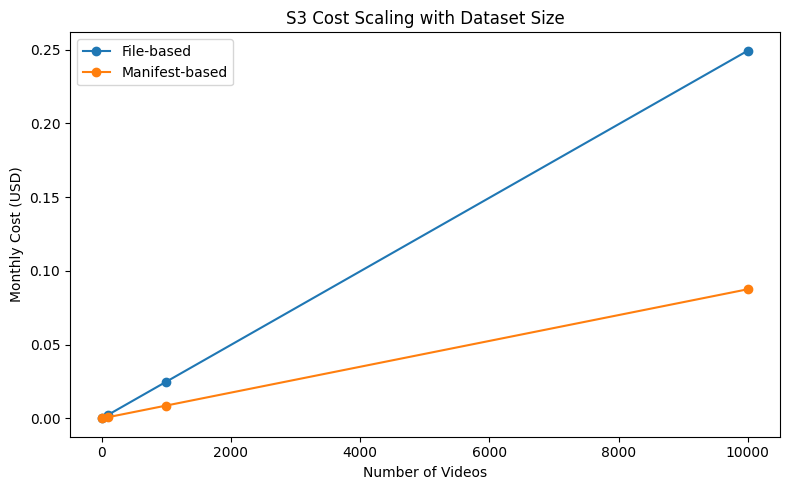

In [86]:
video_counts = np.array([10, 100, 1000, 10000])
file_storage_mb = file_per_video_mb * video_counts
manifest_storage_mb = manifest_per_video_mb * video_counts
file_costs = (file_storage_mb / 1024) * s3_price_per_gb
manifest_costs = (manifest_storage_mb / 1024) * s3_price_per_gb
plt.figure(figsize=(8, 5))
plt.plot(video_counts, file_costs, marker='o', label='File-based')
plt.plot(video_counts, manifest_costs, marker='o', label='Manifest-based')
plt.xlabel("Number of Videos")
plt.ylabel("Monthly Cost (USD)")
plt.title("S3 Cost Scaling with Dataset Size")
plt.legend()
plt.tight_layout()
plt.savefig("graph_cost_scaling_corrected.png", dpi=300, bbox_inches="tight")
plt.show()

## GRID subset comparison (10,000 videos)

This graph shows the estimated total storage required for a 10,000-video GRID subset under both storage approaches.

The manifest-based approach stores frames once and reuses them through manifests, while the file-based approach stores duplicated copies of the same data.

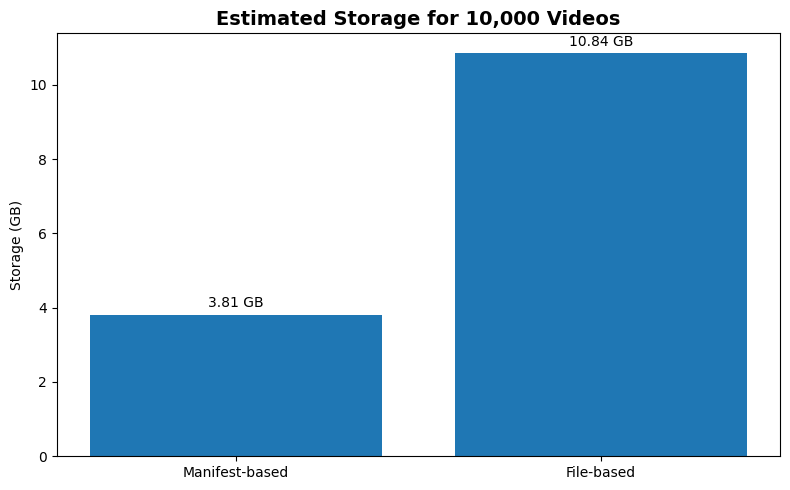

In [87]:
labels = ["Manifest-based", "File-based"]
values = [manifest_grid_10k_gb, file_grid_10k_gb]
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values)
plt.ylabel("Storage (GB)")
plt.title("Estimated Storage for 10,000 Videos", fontsize=14, weight="bold")
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.2, f"{val:.2f} GB", ha='center')
plt.tight_layout()
plt.savefig("graph_storage_10000_videos_corrected.png", dpi=300, bbox_inches="tight")
plt.show()

## GRID subset monthly cost comparison

This graph shows the AWS Calculator monthly S3 storage cost for the 10,000-video GRID subset.

It highlights the additional monthly cost introduced by the file-based approach.

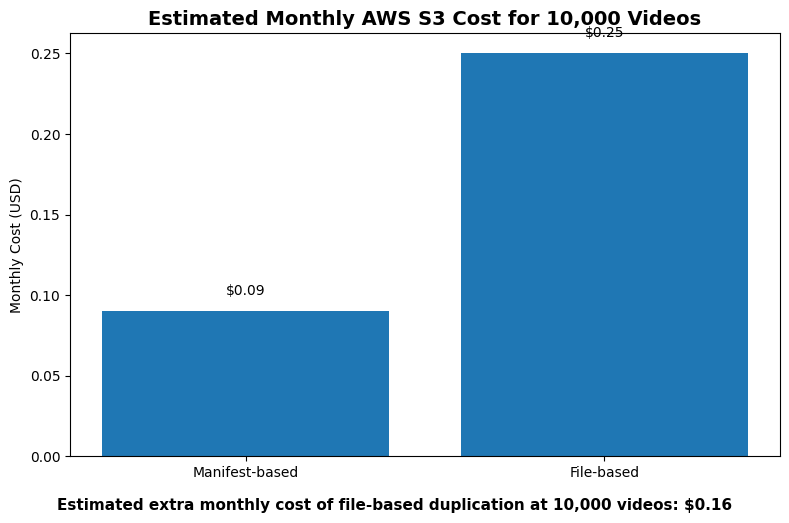

In [88]:
labels = ["Manifest-based", "File-based"]
costs = [manifest_cost_grid_10k_month, file_cost_grid_10k_month]
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, costs)
plt.ylabel("Monthly Cost (USD)")
plt.title("Estimated Monthly AWS S3 Cost for 10,000 Videos", fontsize=14, weight="bold")
for bar, val in zip(bars, costs):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"${val:.2f}", ha='center')
plt.figtext(
    0.5, -0.03,
    f"Estimated extra monthly cost of file-based duplication at 10,000 videos: ${saving_grid_10k_month:.2f}",
    ha="center", fontsize=11, weight="bold")
plt.tight_layout()
plt.savefig("graph_cost_10000_videos_corrected.png", dpi=300, bbox_inches="tight")
plt.show()

## Storage reduction for the 10-video sample

This pie chart shows the proportion of storage used by the manifest-based approach relative to the storage saved by avoiding file duplication.

It illustrates the reduction achieved when frames are stored once and reused through manifest references.

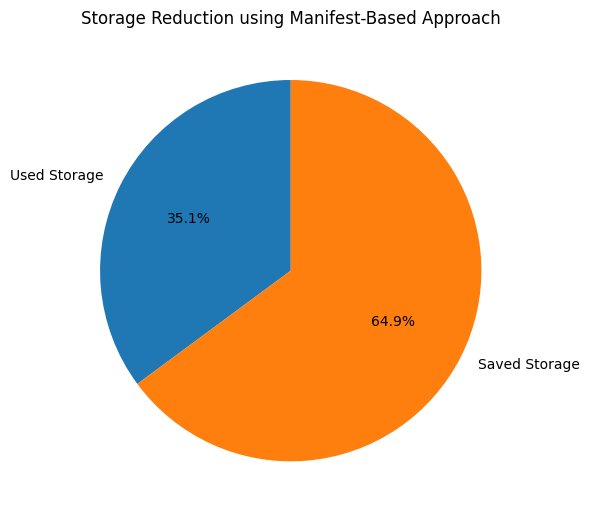

In [89]:
used_pct = (manifest_total_mb_sample / file_total_mb_sample) * 100
saved_pct = storage_saved_pct
plt.figure(figsize=(6, 6))
plt.pie(
    [used_pct, saved_pct],
    labels=["Used Storage", "Saved Storage"],
    autopct='%1.1f%%',
    startangle=90)
plt.title("Storage Reduction using Manifest-Based Approach")
plt.tight_layout()
plt.savefig("graph_storage_pie_corrected.png", dpi=300, bbox_inches="tight")
plt.show()

## Storage breakdown across datasets

This figure compares total storage under manifest-based approach with the additional storage wasted under file-based approach.

The green portion shows the storage required when frames are stored once and reused through manifests.  
The blue portion shows the extra duplicated storage introduced by the file-based approach.

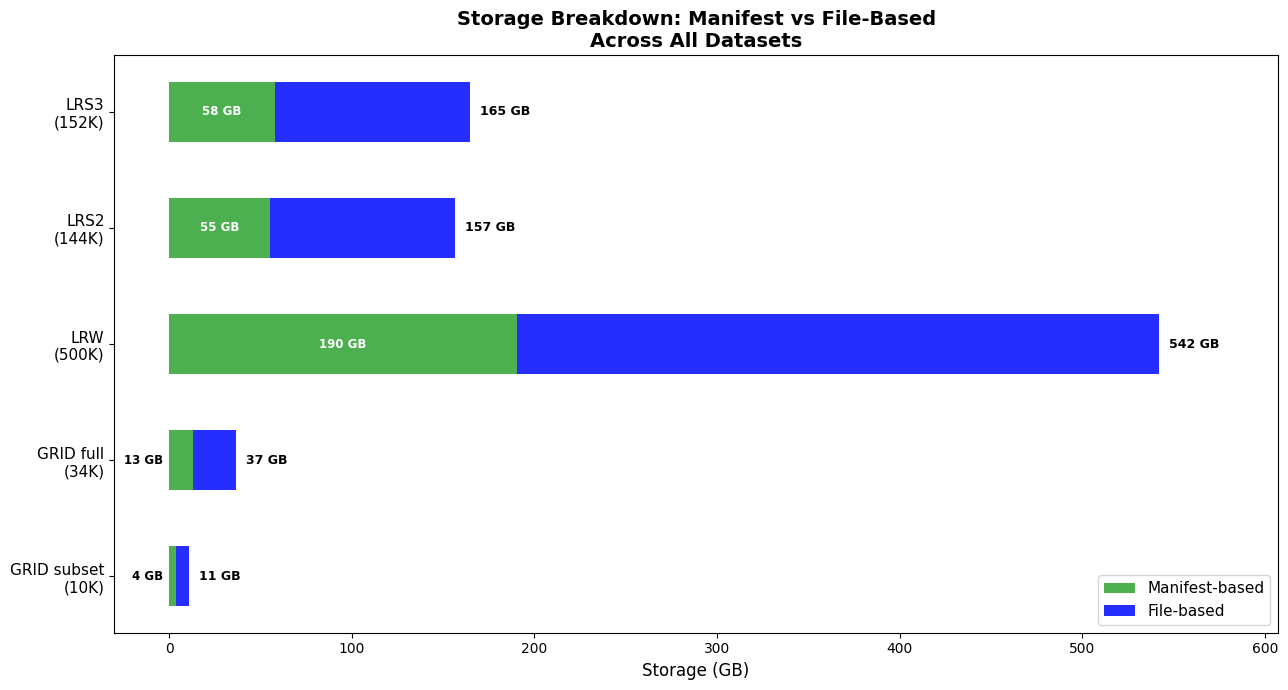

In [90]:
dataset_short_storage_plot = [
    "GRID subset\n(10K)",
    "GRID full\n(34K)",
    "LRW\n(500K)",
    "LRS2\n(144K)",
    "LRS3\n(152K)"]

manifest_gb_v_plot = [
    manifest_grid_10k_gb,
    manifest_grid_34k_gb,
    manifest_lrw_gb,
    manifest_lrs2_gb,
    manifest_lrs3_gb]

wasted_gb_v_plot = [
    wasted_grid_10k_gb,
    wasted_grid_34k_gb,
    wasted_lrw_gb,
    wasted_lrs2_gb,
    wasted_lrs3_gb]

y = np.arange(len(dataset_short_storage_plot))
height = 0.52
fig, ax = plt.subplots(figsize=(13, 7))

ax.barh(
    y,manifest_gb_v_plot,height,
    label='Manifest-based',color='#4caf50')

ax.barh(
    y,wasted_gb_v_plot,height,
    left=manifest_gb_v_plot,label='File-based',
    color='#0008ff',alpha=0.85)

ax.set_xlabel('Storage (GB)', fontsize=12)
ax.set_title('Storage Breakdown: Manifest vs File-Based\nAcross All Datasets',
             fontsize=14, weight='bold')
ax.set_yticks(y)
ax.set_yticklabels(dataset_short_storage_plot, fontsize=11)
ax.legend(fontsize=11, loc='lower right')
# adding space for labels
max_total = max(m + w for m, w in zip(manifest_gb_v_plot, wasted_gb_v_plot))
ax.set_xlim(-30, max_total * 1.12)
for i, (m, w) in enumerate(zip(manifest_gb_v_plot, wasted_gb_v_plot)):
    total = m + w
    ax.text(
        total + max_total * 0.01,i,f'{total:,.0f} GB',
        va='center',ha='left',
        fontsize=9,color='black',weight='bold')
    # Manifest labels
    if m >= 20:
        ax.text(m / 2,i,f'{m:,.0f} GB',
            va='center',ha='center',
            fontsize=8.5,color='white',weight='bold')
    else:
        ax.text(
            -3,i,f'{m:,.0f} GB',
            va='center',ha='right',
            fontsize=8.5,color='black',weight='bold')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('graph_storage_stacked_horizontal.png', dpi=300, bbox_inches='tight')
plt.show()

## Savings comparison across datasets

This figure shows how much storage cost is saved by using the manifest-based approach instead of the file-based approach.

The left chart shows total year savings for each dataset.  
The right chart shows how those savings accumulate over 12-month period.

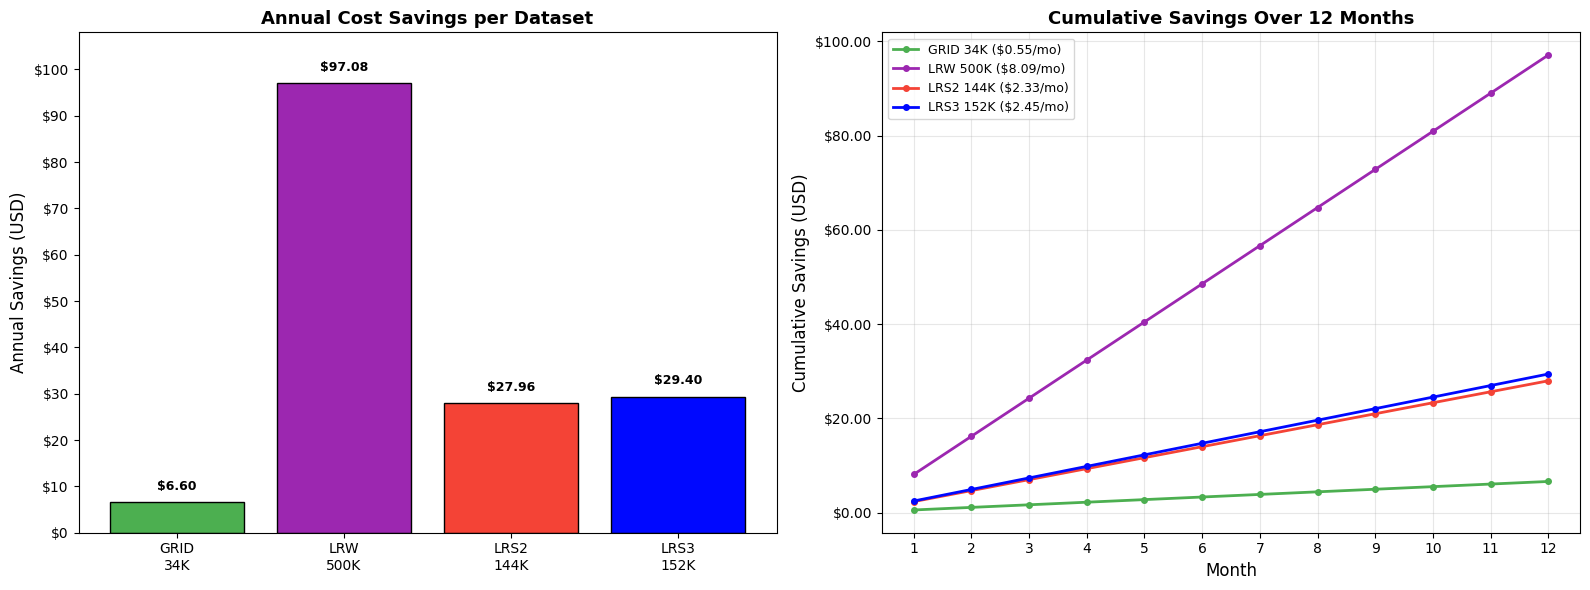

In [92]:
dataset_short_savings_plot = ["GRID\n34K", "LRW\n500K", "LRS2\n144K", "LRS3\n152K"]
annual_savings_plot = [
    saving_grid_34k_year,
    saving_lrw_year,
    saving_lrs2_year,
    saving_lrs3_year]

savings_monthly_plot = [
    saving_grid_34k_month,
    saving_lrw_month,
    saving_lrs2_month,
    saving_lrs3_month]

dataset_labels = ['GRID 34K', 'LRW 500K', 'LRS2 144K', 'LRS3 152K']
dataset_colors = {
    'GRID 34K': '#4caf50',
    'LRW 500K': '#9c27b0',
    'LRS2 144K': '#f44336',
    'LRS3 152K': '#0008ff'}

bar_colors = [dataset_colors[label] for label in dataset_labels]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
bars = ax1.bar(
    dataset_short_savings_plot,
    annual_savings_plot,
    color=bar_colors,
    edgecolor='black',
    linewidth=1)

ax1.set_ylabel('Annual Savings (USD)', fontsize=12)
ax1.set_title('Annual Cost Savings per Dataset', fontsize=13, weight='bold')
max_val = max(annual_savings_plot)
upper = int(np.ceil(max_val / 10.0)) * 10
label_offset = upper * 0.02
top_padding = upper * 0.08
ax1.set_ylim(0, upper + top_padding)
ax1.set_yticks(np.arange(0, upper + 1, 10))
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, annual_savings_plot):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + label_offset,
        f'${val:,.2f}',
        ha='center',
        va='bottom',
        fontsize=9,
        weight='bold')
months = np.arange(1, 13)

for ms, label in zip(savings_monthly_plot, dataset_labels):
    cumulative = [ms * m for m in months]
    ax2.plot(
        months,
        cumulative,
        marker='o',
        markersize=4,
        label=f'{label} (${ms:,.2f}/mo)',
        color=dataset_colors[label],
        linewidth=2)

ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Cumulative Savings (USD)', fontsize=12)
ax2.set_title('Cumulative Savings Over 12 Months', fontsize=13, weight='bold')
ax2.set_xticks(months)
ax2.legend(fontsize=9, loc='upper left')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.2f}'))
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graph_annual_cumulative_savings.png', dpi=300, bbox_inches='tight')
plt.show()

## Cost scaling across datasets

This figure compares the actual AWS Calculator cost of manifest-based and file-based storage across all datasets.

The left chart shows monthly storage cost, and the right chart shows annual storage cost.  
Both charts include:
- GRID subset used in private research (10,000)
- GRID full corpus (34,000)
- BBC LRW (500,000)
- BBC LRS2 (144,482)
- BBC LRS3 (151,819)

All cost values are taken from AWS Calculator results, (defined in Cell 1).

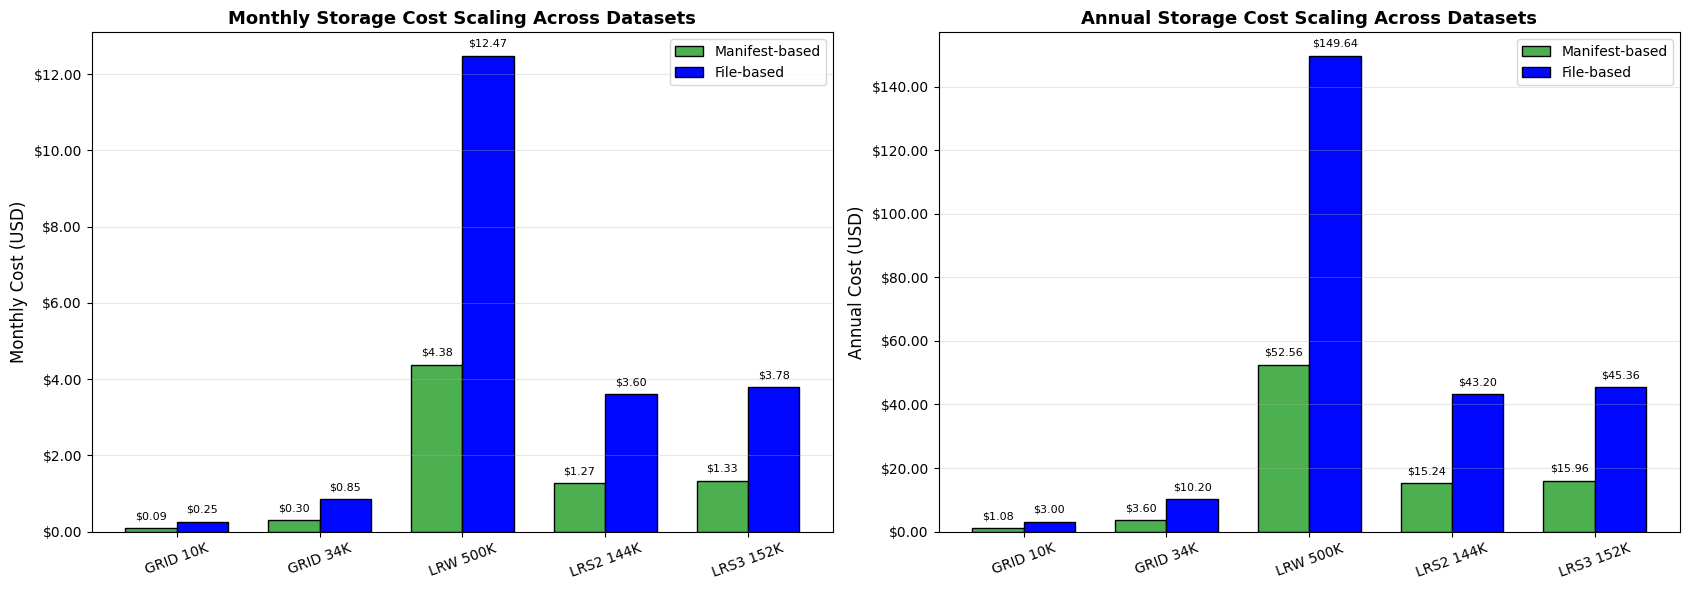

In [94]:
dataset_labels_all = [
    'GRID 10K','GRID 34K','LRW 500K','LRS2 144K','LRS3 152K']

manifest_month_all = [
    manifest_cost_grid_10k_month,
    manifest_cost_grid_34k_month,
    manifest_cost_lrw_month,
    manifest_cost_lrs2_month,
    manifest_cost_lrs3_month]

file_month_all = [
    file_cost_grid_10k_month,
    file_cost_grid_34k_month,
    file_cost_lrw_month,
    file_cost_lrs2_month,
    file_cost_lrs3_month]

manifest_year_all = [
    manifest_cost_grid_10k_year,
    manifest_cost_grid_34k_year,
    manifest_cost_lrw_year,
    manifest_cost_lrs2_year,
    manifest_cost_lrs3_year]

file_year_all = [
    file_cost_grid_10k_year,
    file_cost_grid_34k_year,
    file_cost_lrw_year,
    file_cost_lrs2_year,
    file_cost_lrs3_year]

x = np.arange(len(dataset_labels_all))
width = 0.36
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6))
# Left monthly cost scaling
bars1 = ax1.bar(
    x - width / 2,
    manifest_month_all,
    width,
    label='Manifest-based',
    color='#4caf50',
    edgecolor='black',
    linewidth=1)

bars2 = ax1.bar(
    x + width / 2,
    file_month_all,
    width,
    label='File-based',
    color='#0008ff',
    edgecolor='black',
    linewidth=1)

ax1.set_title('Monthly Storage Cost Scaling Across Datasets', fontsize=13, weight='bold')
ax1.set_ylabel('Monthly Cost (USD)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(dataset_labels_all, rotation=20)
ax1.legend(fontsize=10)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${y:,.2f}'))
ax1.grid(axis='y', alpha=0.3)
monthly_offset = max(file_month_all) * 0.015
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        h + monthly_offset,
        f'${h:,.2f}',
        ha='center',
        va='bottom',
        fontsize=8)

# Right annual cost scaling
bars3 = ax2.bar(
    x - width / 2,
    manifest_year_all,
    width,
    label='Manifest-based',
    color='#4caf50',
    edgecolor='black',
    linewidth=1)

bars4 = ax2.bar(
    x + width / 2,
    file_year_all,
    width,
    label='File-based',
    color='#0008ff',
    edgecolor='black',
    linewidth=1)

ax2.set_title('Annual Storage Cost Scaling Across Datasets', fontsize=13, weight='bold')
ax2.set_ylabel('Annual Cost (USD)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(dataset_labels_all, rotation=20)
ax2.legend(fontsize=10)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${y:,.2f}'))
ax2.grid(axis='y', alpha=0.3)
annual_offset = max(file_year_all) * 0.015
for bar in list(bars3) + list(bars4):
    h = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        h + annual_offset,
        f'${h:,.2f}',
        ha='center',
        va='bottom',
        fontsize=8)

plt.tight_layout()
plt.savefig('graph_cost_scaling_all_datasets.png', dpi=300, bbox_inches='tight')
plt.show()

## File-based vs manifest-based storage design

This diagram compares two approaches to organising frames in S3.

In the file-based approach (left), the same frames are duplicated across multiple viseme systems.

In the manifest-based approach (right), frames are stored once and reused through lightweight JSON manifest files, eliminating duplication and reducing storage usage.

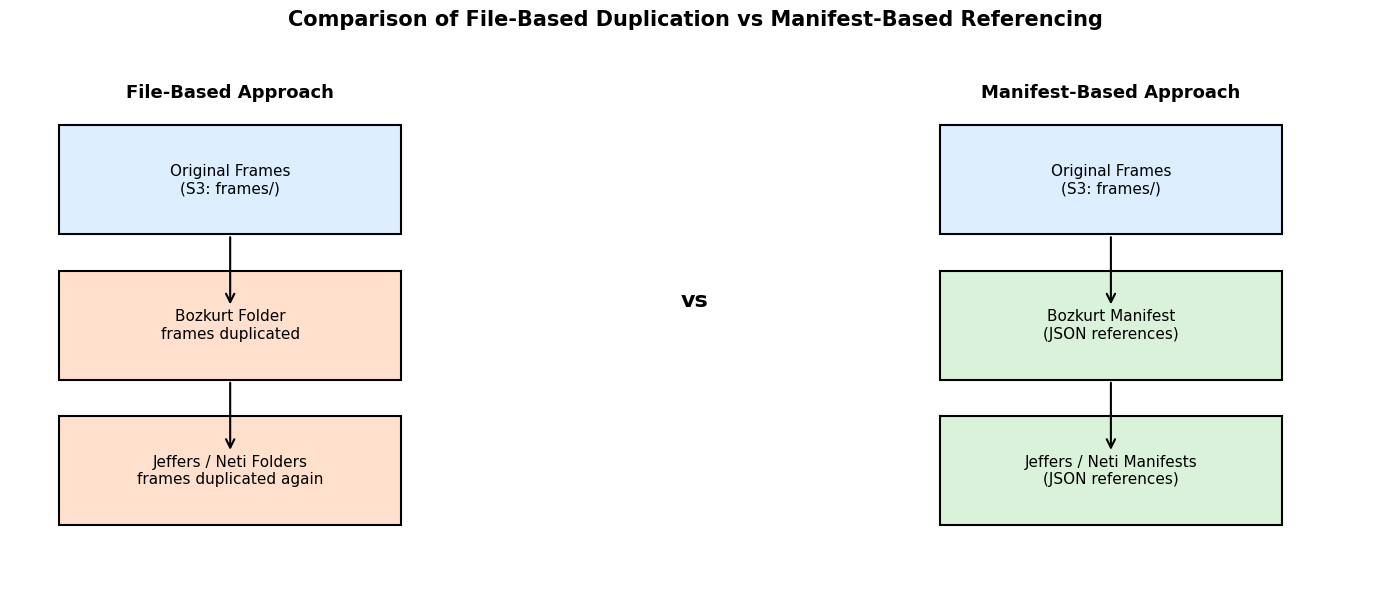

In [95]:
from matplotlib.patches import Rectangle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis("off")

def add_box(x, y, w, h, text, color):
    rect = Rectangle((x, y), w, h, facecolor=color, edgecolor="black", linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=11, wrap=True)

def add_arrow(x1, y1, x2, y2):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                            arrowstyle='->', mutation_scale=15, linewidth=1.5)
    ax.add_patch(arrow)

#left side
add_box(0.5, 3.8, 3.5, 1.2,
        "Original Frames\n(S3: frames/)", "#dceeff")
add_box(0.5, 2.2, 3.5, 1.2,
        "Bozkurt Folder\nframes duplicated", "#ffe0cc")
add_box(0.5, 0.6, 3.5, 1.2,
        "Jeffers / Neti Folders\nframes duplicated again", "#ffe0cc")
add_arrow(2.25, 3.8, 2.25, 3.0)
add_arrow(2.25, 2.2, 2.25, 1.4)
ax.text(2.25, 5.3, "File-Based Approach", ha="center", fontsize=13, weight="bold")
#right side
add_box(9.5, 3.8, 3.5, 1.2,
        "Original Frames\n(S3: frames/)", "#dceeff")
add_box(9.5, 2.2, 3.5, 1.2,
        "Bozkurt Manifest\n(JSON references)", "#d9f2d9")
add_box(9.5, 0.6, 3.5, 1.2,
        "Jeffers / Neti Manifests\n(JSON references)", "#d9f2d9")
add_arrow(11.25, 3.8, 11.25, 3.0)
add_arrow(11.25, 2.2, 11.25, 1.4)
ax.text(11.25, 5.3, "Manifest-Based Approach", ha="center", fontsize=13, weight="bold")
#center
ax.text(7, 3, "vs", fontsize=16, weight="bold", ha="center")
plt.title("Comparison of File-Based Duplication vs Manifest-Based Referencing",
          fontsize=15, weight="bold")
plt.tight_layout()
plt.savefig("figure2_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Lambda functions used in the project

The following cells include AWS Lambda functions implemented in the project.

Cells are not runnable in Colab, they are included for reference to support understanding of the system design.


##load_mapping_to_dynamodb

This function loads phoneme-to-viseme mapping data from JSON files into DynamoDB.

In [16]:
import json
import boto3

s3 = boto3.client("s3")
dynamodb = boto3.resource("dynamodb")
TABLE_NAME = "phoneme_viseme_mapping"
DEFAULT_BUCKET = "cloud-project-lipreading"
table = dynamodb.Table(TABLE_NAME)

def lambda_handler(event, context):
    bucket = event.get("bucket", DEFAULT_BUCKET)
    input_key = event.get("input_key")
    if not input_key:
        return {
            "statusCode": 400,
            "message": "No input_key provided"}

    response = s3.get_object(Bucket=bucket, Key=input_key)
    data = json.loads(response["Body"].read())
    if not isinstance(data, list):
        return {
            "statusCode": 400,
            "message": "Mapping file must contain a JSON array"}
    inserted = 0
    for item in data:
        phoneme = item.get("phoneme")
        mapping = item.get("mapping")
        viseme = item.get("viseme")
        if not phoneme or not mapping or not viseme:
            continue
        table.put_item(
            Item={
                "phoneme": str(phoneme).upper().strip(),
                "mapping": str(mapping).lower().strip(),
                "viseme": str(viseme).strip()})
        inserted += 1

    return {
        "statusCode": 200,
        "message": "Mapping file loaded successfully",
        "input_file": input_key,
        "items_inserted": inserted}

##search_viseme_mapping

This function retrieves viseme mappings from DynamoDB in response to API queries.

In [ ]:
import json
import boto3
from boto3.dynamodb.conditions import Key

dynamodb = boto3.resource("dynamodb")
table = dynamodb.Table("phoneme_viseme_mapping")

def lambda_handler(event, context):
    params = event.get("queryStringParameters") or {}
    phoneme = params.get("phoneme")
    mapping = params.get("mapping")
    if not phoneme:
        return {
            "statusCode": 400,
            "headers": {"Content-Type": "application/json"},
            "body": json.dumps({
                "message": "Missing required query parameter: phoneme"
            })
        }

    phoneme = phoneme.upper().strip()
    # Specific mapping search
    if mapping:
        mapping = mapping.lower().strip()
        response = table.get_item(
            Key={
                "phoneme": phoneme,
                "mapping": mapping
            }
        )
        item = response.get("Item")
        return {
            "statusCode": 200,
            "headers": {"Content-Type": "application/json"},
            "body": json.dumps({
                "phoneme": phoneme,
                "results": [item] if item else []
            })
        }

    # All mappings for phoneme
    response = table.query(
        KeyConditionExpression=Key("phoneme").eq(phoneme))
    items = response.get("Items", [])
    # Sort results
    items = sorted(items, key=lambda x: x.get("mapping", ""))
    if not items:
        return {
            "statusCode": 404,
            "headers": {"Content-Type": "application/json"},
            "body": json.dumps({
                "phoneme": phoneme,
                "message": "No mappings found",
                "results": []
            })
        }

    return {
        "statusCode": 200,
        "headers": {"Content-Type": "application/json"},
        "body": json.dumps({
            "phoneme": phoneme,
            "results": items
        })
    }


##generate_viseme_manifest

This function generates manifest files by mapping phoneme intervals to viseme labels.

A regular expression pattern with named capture groups was used to extract information from frame filenames.



In [ ]:
import json
import boto3
import re
import os
from urllib.parse import unquote_plus

s3 = boto3.client("s3")
dynamodb = boto3.resource("dynamodb")
TABLE_NAME = "phoneme_viseme_mapping"
DEFAULT_BUCKET = "cloud-project-lipreading"
MAPPING_SYSTEMS = ["bozkurt", "jeffers", "neti"]
table = dynamodb.Table(TABLE_NAME)

def normalize_phoneme(phoneme: str) -> str:
    if not phoneme:
        return ""
    phoneme = phoneme.upper().strip()
    phoneme = re.sub(r"\d+$", "", phoneme)
    return phoneme

def get_viseme(phoneme: str, mapping: str) -> str:
    response = table.get_item(
        Key={
            "phoneme": phoneme,
            "mapping": mapping
        })
    item = response.get("Item")
    if item:
        return item["viseme"]
    return "UNKNOWN"

def build_output_key(input_key: str, mapping_system: str) -> str:
    filename = os.path.basename(input_key)
    base_name = filename.replace("_phoneme_intervals_mfa.json", "")
    return f"manifests/{base_name}_{mapping_system}_viseme_manifest.json"


def extract_video_id(input_key: str) -> str:
    filename = os.path.basename(input_key)
    return filename.replace("_phoneme_intervals_mfa.json", "")

def list_frame_files(bucket: str, video_id: str):
    prefix = f"raw-grid-dataset/frames/{video_id}/"
    response = s3.list_objects_v2(Bucket=bucket, Prefix=prefix)
    frames = []
    for obj in response.get("Contents", []):
        key = obj["Key"]
        if not key.lower().endswith(".jpg"):
            continue
        filename = os.path.basename(key)
        # try to match file name example bbab8n_002_B_0.540s.jpg
        match = re.match(
            r"^(?P<video>[a-zA-Z0-9]+)_(?P<idx>\d+)_(?P<phoneme>[A-Z\-]+)_(?P<ts>\d+\.\d+)s\.jpg$",
            filename)
        if not match:
            continue
        frames.append({
            "filename": filename,
            "s3_key": key,
            "index": int(match.group("idx")),
            "phoneme": normalize_phoneme(match.group("phoneme")),
            "timestamp": float(match.group("ts"))})
    frames.sort(key=lambda x: x["index"])
    return frames

def attach_frames_to_intervals(bucket: str, video_id: str, phoneme_intervals: list):
    frames = list_frame_files(bucket, video_id)
    matched_intervals = []
    frame_pointer = 0
    for interval in phoneme_intervals:
        phoneme = normalize_phoneme(interval.get("phoneme", ""))
        interval_copy = dict(interval)
        interval_copy["phoneme"] = phoneme
        interval_copy["frame_s3_key"] = None
        interval_copy["frame_filename"] = None
        if phoneme == "SIL":
            matched_intervals.append(interval_copy)
            continue
        matched = False
        for i in range(frame_pointer, len(frames)):
            if frames[i]["phoneme"] == phoneme:
                interval_copy["frame_s3_key"] = frames[i]["s3_key"]
                interval_copy["frame_filename"] = frames[i]["filename"]
                frame_pointer = i + 1
                matched = True
                break
        if not matched:
            start_time = interval.get("start_time", 0)
            same_phoneme_frames = [f for f in frames if f["phoneme"] == phoneme]
            if same_phoneme_frames:
                nearest = min(
                    same_phoneme_frames,
                    key=lambda f: abs(f["timestamp"] - start_time))
                interval_copy["frame_s3_key"] = nearest["s3_key"]
                interval_copy["frame_filename"] = nearest["filename"]
        matched_intervals.append(interval_copy)
    return matched_intervals


def create_manifest(data: dict, input_key: str, mapping_system: str, bucket: str) -> dict:
    phoneme_intervals = data.get("phoneme_intervals", [])
    video_id = extract_video_id(input_key)
    matched_intervals = attach_frames_to_intervals(bucket, video_id, phoneme_intervals)
    viseme_intervals = []
    for interval in matched_intervals:
        phoneme = normalize_phoneme(interval.get("phoneme", ""))
        viseme = get_viseme(phoneme, mapping_system)
        viseme_intervals.append({
            "phoneme": phoneme,
            "viseme": viseme,
            "start_time": interval.get("start_time"),
            "end_time": interval.get("end_time"),
            "duration": interval.get("duration"),
            "start_frame": interval.get("start_frame"),
            "end_frame": interval.get("end_frame"),
            "frame_count": interval.get("frame_count"),
            "word": interval.get("word", None),
            "frame_s3_key": interval.get("frame_s3_key"),
            "frame_filename": interval.get("frame_filename")})

    output = {
        "video": data.get("video"),
        "video_id": video_id,
        "transcript": data.get("transcript"),
        "alignment_method": data.get("alignment_method"),
        "mapping_system": mapping_system,
        "source_alignment_file": input_key,
        "phoneme_count": len(phoneme_intervals),
        "viseme_count": len(viseme_intervals),
        "viseme_intervals": viseme_intervals}
    return output


def lambda_handler(event, context):
    bucket = DEFAULT_BUCKET
    input_key = None
    if isinstance(event, dict):
        bucket = event.get("bucket", DEFAULT_BUCKET)
        input_key = event.get("input_key")
    if not input_key and "Records" in event:
        record = event["Records"][0]
        bucket = record["s3"]["bucket"]["name"]
        input_key = unquote_plus(record["s3"]["object"]["key"])
    if not input_key:
        return {
            "statusCode": 400,
            "message": "No input_key provided"}
    response = s3.get_object(Bucket=bucket, Key=input_key)
    data = json.loads(response["Body"].read())
    created_files = []
    for mapping_system in MAPPING_SYSTEMS:
        output_key = build_output_key(input_key, mapping_system)
        output_manifest = create_manifest(data, input_key, mapping_system, bucket)
        s3.put_object(
            Bucket=bucket,
            Key=output_key,
            Body=json.dumps(output_manifest, indent=2),
            ContentType="application/json")
        created_files.append(output_key)

    return {
        "statusCode": 200,
        "message": "Viseme manifests with frame references created successfully",
        "input_file": input_key,
        "created_files": created_files,
        "mapping_systems_processed": MAPPING_SYSTEMS}

##duplicate_frames_by_viseme

This function creates duplicated frame datasets for each viseme scheme for comparison purposes.

In [ ]:
import json
import boto3
import os
from urllib.parse import unquote_plus

s3 = boto3.client("s3")
DEFAULT_BUCKET = "cloud-project-lipreading"

def build_destination_key(mapping_system: str, viseme: str, video_id: str, filename: str) -> str:
    return f"processed/file-based/{mapping_system}/{viseme}/{video_id}/{filename}"

def lambda_handler(event, context):
    bucket = DEFAULT_BUCKET
    input_key = None
    # Manual test support
    if isinstance(event, dict):
        bucket = event.get("bucket", DEFAULT_BUCKET)
        input_key = event.get("input_key")
    # S3 trigger support
    if not input_key and "Records" in event:
        record = event["Records"][0]
        bucket = record["s3"]["bucket"]["name"]
        input_key = unquote_plus(record["s3"]["object"]["key"])
    if not input_key:
        return {
            "statusCode": 400,
            "message": "No input_key provided"}
    # Read manifest
    response = s3.get_object(Bucket=bucket, Key=input_key)
    manifest = json.loads(response["Body"].read())
    mapping_system = manifest.get("mapping_system")
    video_id = manifest.get("video_id")
    if not mapping_system or not video_id:
        return {
            "statusCode": 400,
            "message": "Manifest missing mapping_system or video_id"}
    copied = 0
    skipped = 0
    copied_files = []
    for interval in manifest.get("viseme_intervals", []):
        frame_s3_key = interval.get("frame_s3_key")
        frame_filename = interval.get("frame_filename")
        viseme = interval.get("viseme")
        # Skiping SIL or missing frame
        if not frame_s3_key or not frame_filename or not viseme:
            skipped += 1
            continue

        destination_key = build_destination_key(
            mapping_system=mapping_system,
            viseme=viseme,
            video_id=video_id,
            filename=frame_filename)

        s3.copy_object(
            Bucket=bucket,
            CopySource={"Bucket": bucket, "Key": frame_s3_key},
            Key=destination_key)

        copied += 1
        copied_files.append(destination_key)

    return {
        "statusCode": 200,
        "message": "Frames duplicated by viseme successfully",
        "manifest_file": input_key,
        "mapping_system": mapping_system,
        "video_id": video_id,
        "frames_copied": copied,
        "frames_skipped": skipped,
        "sample_outputs": copied_files[:10]}